## CMPINF 2100 Week 07

### Reshaping from WIDE to LONG via melt

We have seen how to explore our data. Focusing on the RELATIONSHIP between continuous variables this week.

But, we have also continued to see how important it is to GROUP BY or CONDITION ON categorical variables.

There is an important DATA MANIPULATION task that will further help us use GROUPING to visually explore our data!!!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns

## Read data

In [2]:
penguins = sns.load_dataset('penguins')

In [3]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


## Why we need this operation

We know how to look for a marginal distribution for a SINGLE variable

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


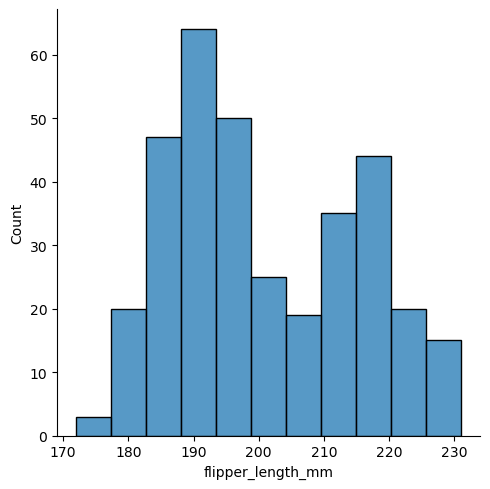

In [12]:
sns.displot(data = penguins, x='flipper_length_mm', kind='hist', bins=11)
plt.show()

import numpy as np
bins = int(np.sqrt(len(penguins)))
print(bins)  # gives a good starting point

`bins` controls **how many bars** appear in the histogram — it determines how you "group" the data.

---

**Why it matters:**

- **Too few bins** (e.g. `bins=3`) — bars are too wide, hides the shape of the distribution, loses detail
- **Too many bins** (e.g. `bins=100`) — bars are too narrow, looks spiky/noisy, hard to see the pattern
- **Just right** (e.g. `bins=12`) — reveals the true shape of the distribution clearly

---

**Without `bins`**, seaborn picks a default automatically — it may not always be the best choice for your data.

---

**Example to see the difference:**
```python
# Too few
sns.displot(data=penguins, x='flipper_length_mm', kind='hist', bins=3)

# Default (no bins specified)
sns.displot(data=penguins, x='flipper_length_mm', kind='hist')

# Tutor's choice
sns.displot(data=penguins, x='flipper_length_mm', kind='hist', bins=12)

# Too many
sns.displot(data=penguins, x='flipper_length_mm', kind='hist', bins=50)
```

---

**Rule of thumb:** Start with the **square root of the number of rows** as a reasonable bin count:

```python
import numpy as np
bins = int(np.sqrt(len(penguins)))
print(bins)  # gives a good starting point
```

There's no single "correct" value — it's about finding what best reveals the **shape and pattern** in your data.

But...to visualize every continuous variable's histogram...we need to CALL a lot of functions

We need to iterate over all the continuous columns!!!

You might think we can use a for-loop! But you would be WRONG!!!

Instead...we want to use a simple line of code to show ALL continuous variable MARGINAL distributions in one figure!!!

pandas allow this

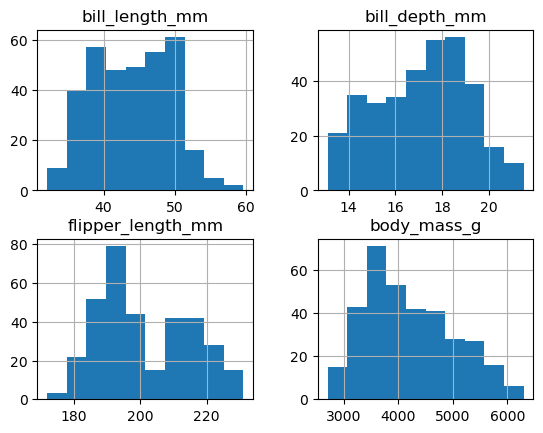

In [13]:
penguins.hist()
plt.show()

But what if I don't want to use Pandas? What if I want to use Seaborn?

What happens if we use the same style of syntax for Seaborn as we did with Pandas?

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


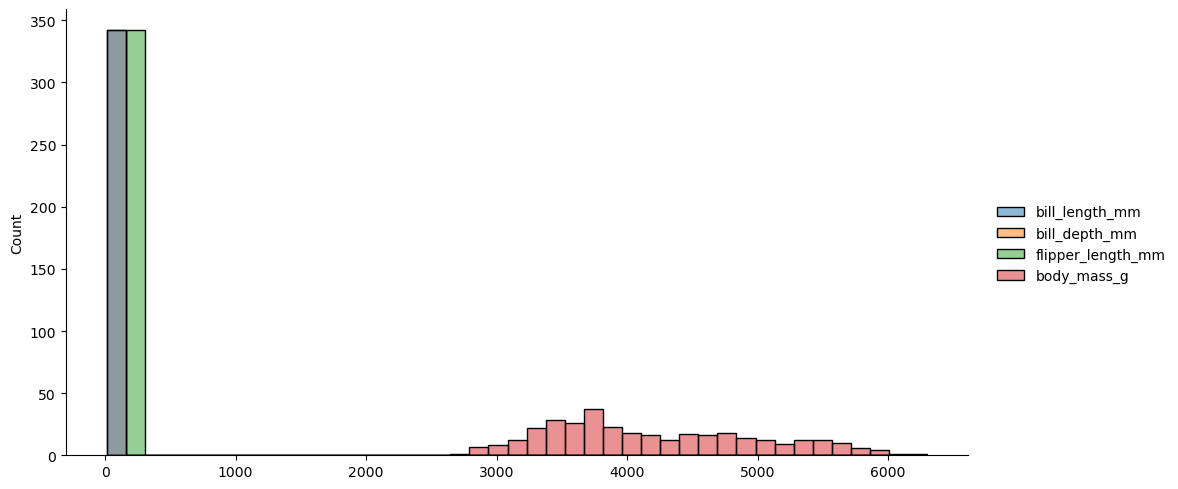

In [15]:
sns.displot( data = penguins, kind='hist', aspect=2)
plt.show()

Let's use the similar synatax to mak a BOXPLOT!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


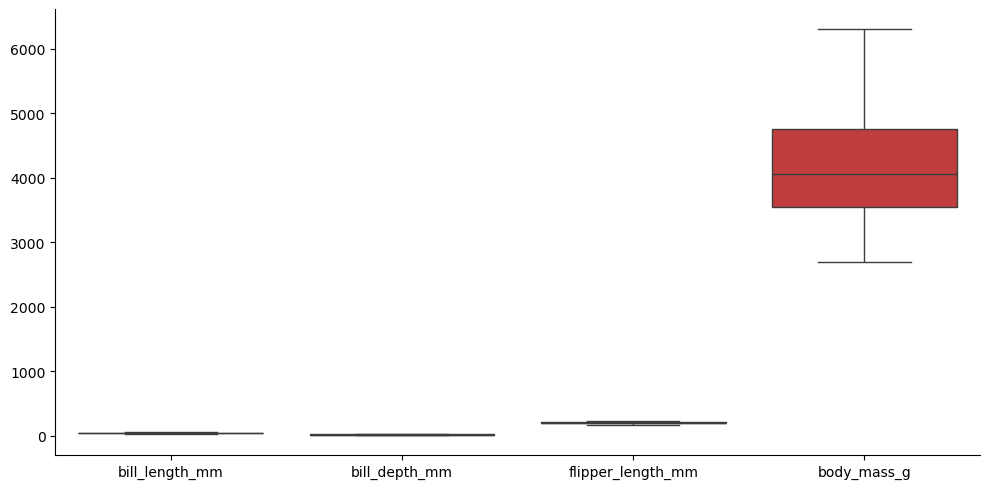

In [16]:
sns.catplot(data = penguins, kind='box', aspect=2)
plt.show()

The SCALE is completely dominated by a single column (variable). That's why we could NOT see all of the histograms using the default Seaborn function!

Instead, we want Seaborn to create separate FACETS for each column just as Pandas did.

But...Seaborn PREFERS data in a DIFFERENT format from Pandas

Pandas like **WIDE FORMAT** data where each column is a VARIABLE

Seaborn however prefers **Long Format** data...where we have a column that denotes the variables!!!

Let's execute RESHAPING from WIDE to LONG format to see what long format does!!!

## Long Format

Let's begin by focusing JUST on the numeric columns. Let's separate out

In [17]:
penguins_features = penguins.select_dtypes('number').copy()

In [19]:
penguins_features

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


To STACK or GATHER all 4 columns in the CURRENT WIDE FORMAT into LONG FORMAT...we need to **MELT** the data.

RESHAPING from WIDE to LONG is accomplished with the `.melt()` method.

In [21]:
penguins_features.melt()

,variable,value
0,bill_length_mm,39.1
1,bill_length_mm,39.5
2,bill_length_mm,40.3
3,bill_length_mm,NaN
4,bill_length_mm,36.7
...,...,...
1371,body_mass_g,NaN
1372,body_mass_g,4850.0
1373,body_mass_g,5750.0
1374,body_mass_g,5200.0


In [22]:
penguins_features.melt().variable.value_counts()

variable
bill_length_mm       344
bill_depth_mm        344
flipper_length_mm    344
body_mass_g          344
Name: count, dtype: int64

In [23]:
penguins_features.shape[0]

344

In [27]:
penguins_features.melt().shape

(1376, 2)

In [28]:
344*4

1376

In [29]:
penguins_features.melt()

,variable,value
0,bill_length_mm,39.1
1,bill_length_mm,39.5
2,bill_length_mm,40.3
3,bill_length_mm,NaN
4,bill_length_mm,36.7
...,...,...
1371,body_mass_g,NaN
1372,body_mass_g,4850.0
1373,body_mass_g,5750.0
1374,body_mass_g,5200.0


By default we LOSE the original `.index()` attribute when we MELT. Meaning we lose which row the data originally came from.

We can KEEP the original `.index` by setting the `ignore_index` argument to False!

In [30]:
penguins_features.melt(ignore_index=False)

,variable,value
0,bill_length_mm,39.1
1,bill_length_mm,39.5
2,bill_length_mm,40.3
3,bill_length_mm,NaN
4,bill_length_mm,36.7
...,...,...
339,body_mass_g,NaN
340,body_mass_g,4850.0
341,body_mass_g,5750.0
342,body_mass_g,5200.0


In [31]:
penguins_features.melt(ignore_index=False).loc[0]

,variable,value
0,bill_length_mm,39.1
0,bill_depth_mm,18.7
0,flipper_length_mm,181.0
0,body_mass_g,3750.0


In [32]:
penguins_features

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


I prefer to CONVERT the `.index` attribute into a REGULAR column and RENAME it to `rowid`

We do NOT want to GATHER or STACK the `rowid` column with the other variable!

Instead, we need to specifically that the `rowid` column uniquely DEFINES the ROW ID!

In [37]:
penguins_features.reset_index().\
rename(columns={'index':'rowid'}).\
melt(id_vars=['rowid'])

,rowid,variable,value
0,0,bill_length_mm,39.1
1,1,bill_length_mm,39.5
2,2,bill_length_mm,40.3
3,3,bill_length_mm,NaN
4,4,bill_length_mm,36.7
...,...,...,...
1371,339,body_mass_g,NaN
1372,340,body_mass_g,4850.0
1373,341,body_mass_g,5750.0
1374,342,body_mass_g,5200.0


In [38]:
lf = penguins_features.reset_index().\
rename(columns={'index':'rowid'}).\
melt(id_vars=['rowid'])

In [41]:
lf.loc[ lf.rowid == 0, : ]

,rowid,variable,value
0,0,bill_length_mm,39.1
344,0,bill_depth_mm,18.7
688,0,flipper_length_mm,181.0
1032,0,body_mass_g,3750.0


In [43]:
penguins_features

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,39.1,18.7,181.0,3750.0
1,39.5,17.4,186.0,3800.0
2,40.3,18.0,195.0,3250.0
3,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0
...,...,...,...,...
339,NaN,NaN,NaN,NaN
340,46.8,14.3,215.0,4850.0
341,50.4,15.7,222.0,5750.0
342,45.2,14.8,212.0,5200.0


The original `penguins` DataFrame had NON-NUMERIC columns!

In [44]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [45]:
penguins_objects = penguins.select_dtypes('object').copy()

In [46]:
penguins_objects

,species,island,sex
0,Adelie,Torgersen,Male
1,Adelie,Torgersen,Female
2,Adelie,Torgersen,Female
3,Adelie,Torgersen,NaN
4,Adelie,Torgersen,Female
...,...,...,...
339,Gentoo,Biscoe,NaN
340,Gentoo,Biscoe,Female
341,Gentoo,Biscoe,Male
342,Gentoo,Biscoe,Female


Let's define a list that contains the `rowid` column and the 3 object column names!

This list will therefore hold ALL columns that uniquely define ROW!!!!

In [47]:
id_cols = ['rowid'] + penguins_objects.columns.to_list()

In [48]:
id_cols

['rowid', 'species', 'island', 'sex']

We can `id_cols` to identify the columns to NOT gather or STACK when we call `.melt()` method on the original data set!

In [49]:
penguins.reset_index().\
rename(columns={'index': 'rowid'}).\
melt(id_vars=id_cols)

,rowid,species,island,sex,variable,value
0,0,Adelie,Torgersen,Male,bill_length_mm,39.1
1,1,Adelie,Torgersen,Female,bill_length_mm,39.5
2,2,Adelie,Torgersen,Female,bill_length_mm,40.3
3,3,Adelie,Torgersen,NaN,bill_length_mm,NaN
4,4,Adelie,Torgersen,Female,bill_length_mm,36.7
...,...,...,...,...,...,...
1371,339,Gentoo,Biscoe,NaN,body_mass_g,NaN
1372,340,Gentoo,Biscoe,Female,body_mass_g,4850.0
1373,341,Gentoo,Biscoe,Male,body_mass_g,5750.0
1374,342,Gentoo,Biscoe,Female,body_mass_g,5200.0


To be very precise we can even identify the columns to GATHER via `value_vars` argument

In [50]:
penguins.reset_index().\
rename(columns={'index': 'rowid'}).\
melt(id_vars=id_cols, value_vars=penguins_features.columns)

,rowid,species,island,sex,variable,value
0,0,Adelie,Torgersen,Male,bill_length_mm,39.1
1,1,Adelie,Torgersen,Female,bill_length_mm,39.5
2,2,Adelie,Torgersen,Female,bill_length_mm,40.3
3,3,Adelie,Torgersen,NaN,bill_length_mm,NaN
4,4,Adelie,Torgersen,Female,bill_length_mm,36.7
...,...,...,...,...,...,...
1371,339,Gentoo,Biscoe,NaN,body_mass_g,NaN
1372,340,Gentoo,Biscoe,Female,body_mass_g,4850.0
1373,341,Gentoo,Biscoe,Male,body_mass_g,5750.0
1374,342,Gentoo,Biscoe,Female,body_mass_g,5200.0


Let's assign this to a new object

In [51]:
penguins_lf = penguins.reset_index().\
rename(columns={'index': 'rowid'}).\
melt(id_vars=id_cols, value_vars=penguins_features.columns)

In [52]:
penguins_lf

,rowid,species,island,sex,variable,value
0,0,Adelie,Torgersen,Male,bill_length_mm,39.1
1,1,Adelie,Torgersen,Female,bill_length_mm,39.5
2,2,Adelie,Torgersen,Female,bill_length_mm,40.3
3,3,Adelie,Torgersen,NaN,bill_length_mm,NaN
4,4,Adelie,Torgersen,Female,bill_length_mm,36.7
...,...,...,...,...,...,...
1371,339,Gentoo,Biscoe,NaN,body_mass_g,NaN
1372,340,Gentoo,Biscoe,Female,body_mass_g,4850.0
1373,341,Gentoo,Biscoe,Male,body_mass_g,5750.0
1374,342,Gentoo,Biscoe,Female,body_mass_g,5200.0


## Plotting with Long Format
We can associate the `variable` column with FACETS in Seaborn!!!

So let's call the `sns.displot()` function again but this time with the LONG FORMAT data and assigning `col` to `variable`

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


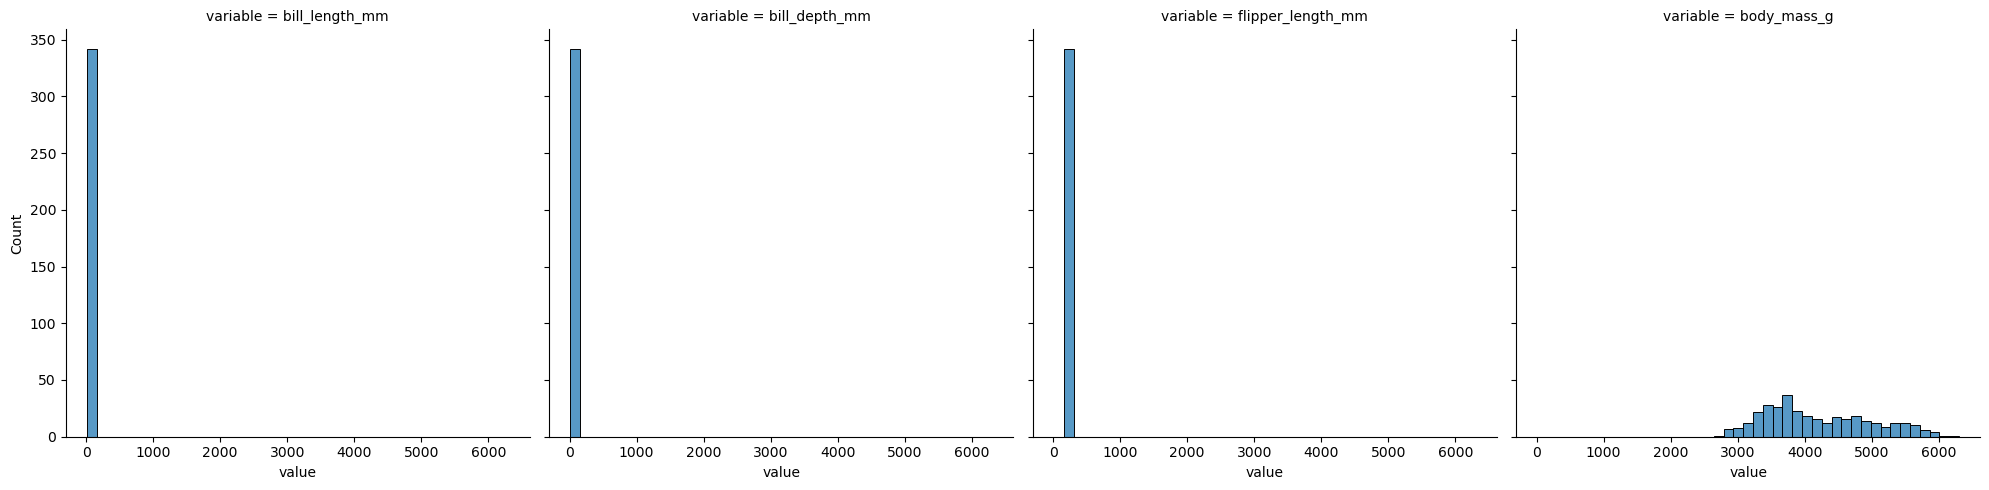

In [53]:
sns.displot(data = penguins_lf, x='value', col='variable', kind='hist')
plt.show()

We need to force FREE or NOT SHARING x and y axis scales

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


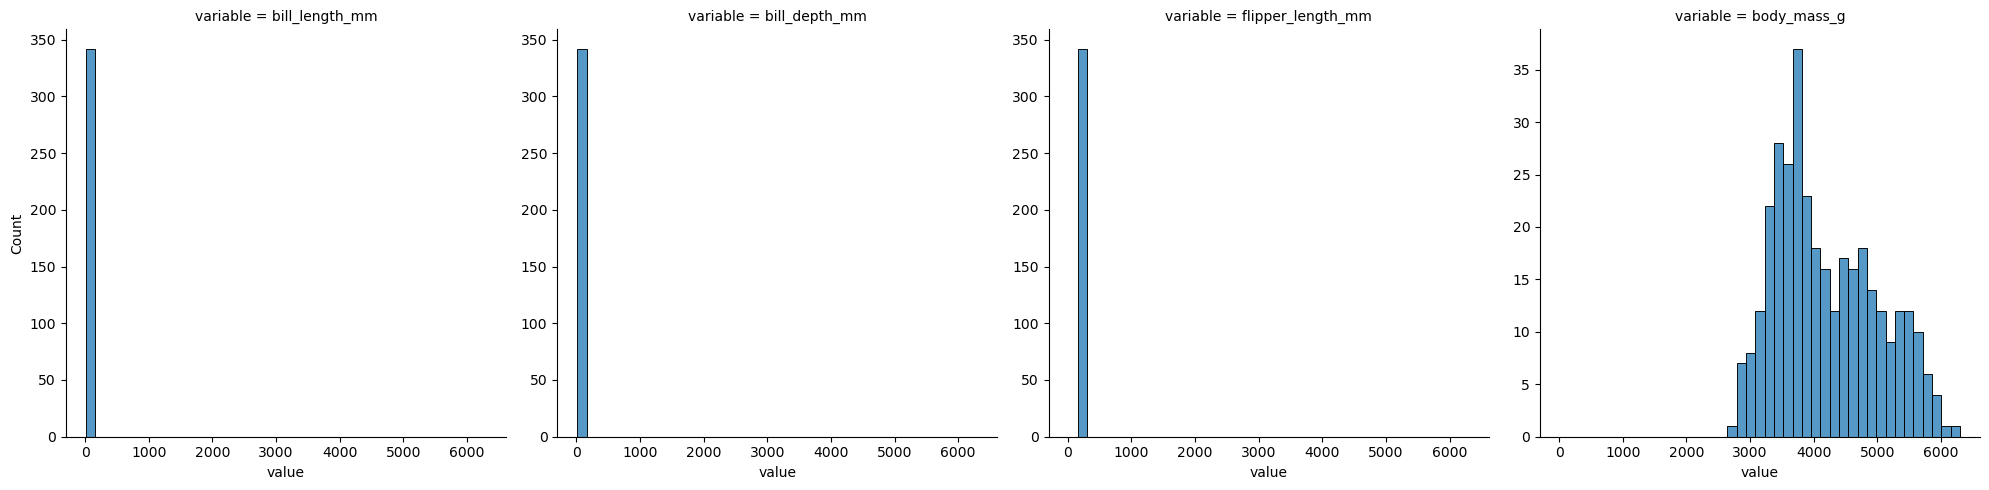

In [55]:
sns.displot(data = penguins_lf, x='value', col='variable', kind='hist',
           facet_kws={'sharex':False, 'sharey':False})
plt.show()

By default the histograms want to use the common bins in all facets...

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


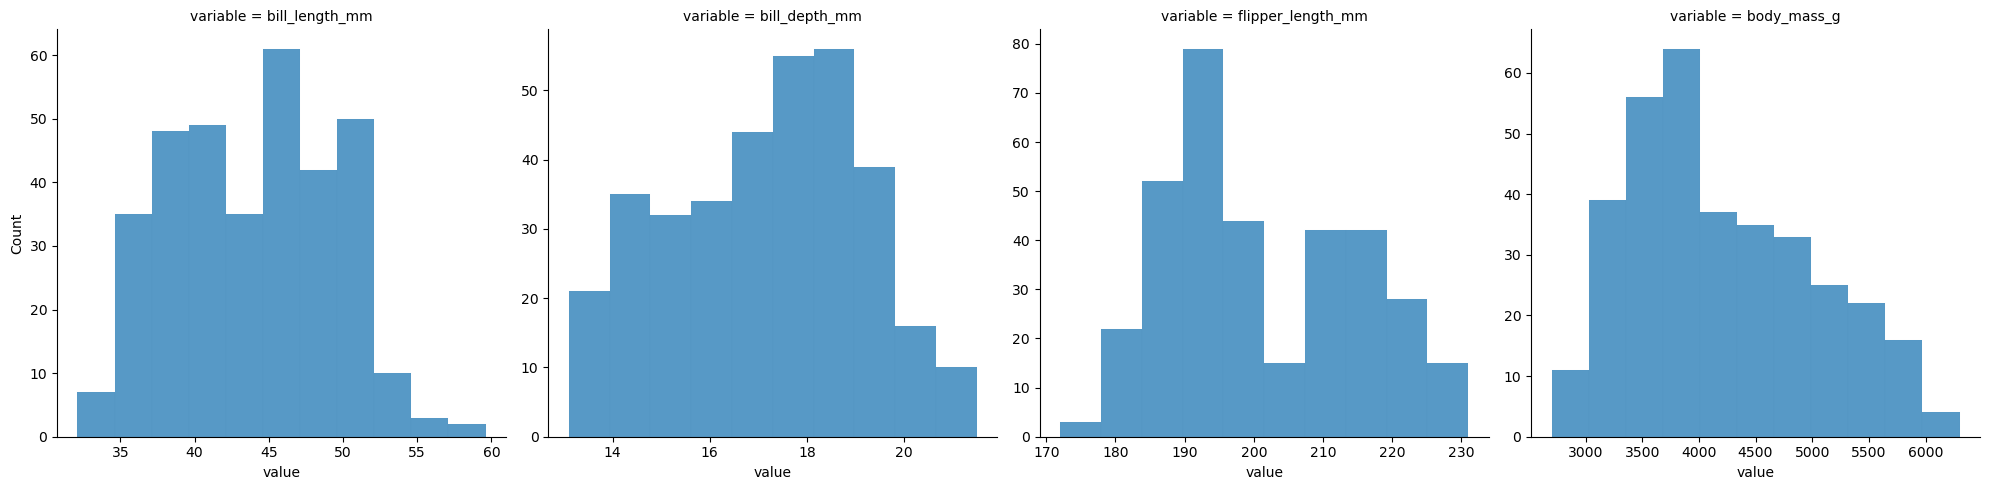

In [56]:
sns.displot(data = penguins_lf, x='value', col='variable', kind='hist',
           facet_kws={'sharex':False, 'sharey':False},
           common_bins=False)
plt.show()

We can do the same thing with KDE plots...but remember common_norm must be FALSE!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


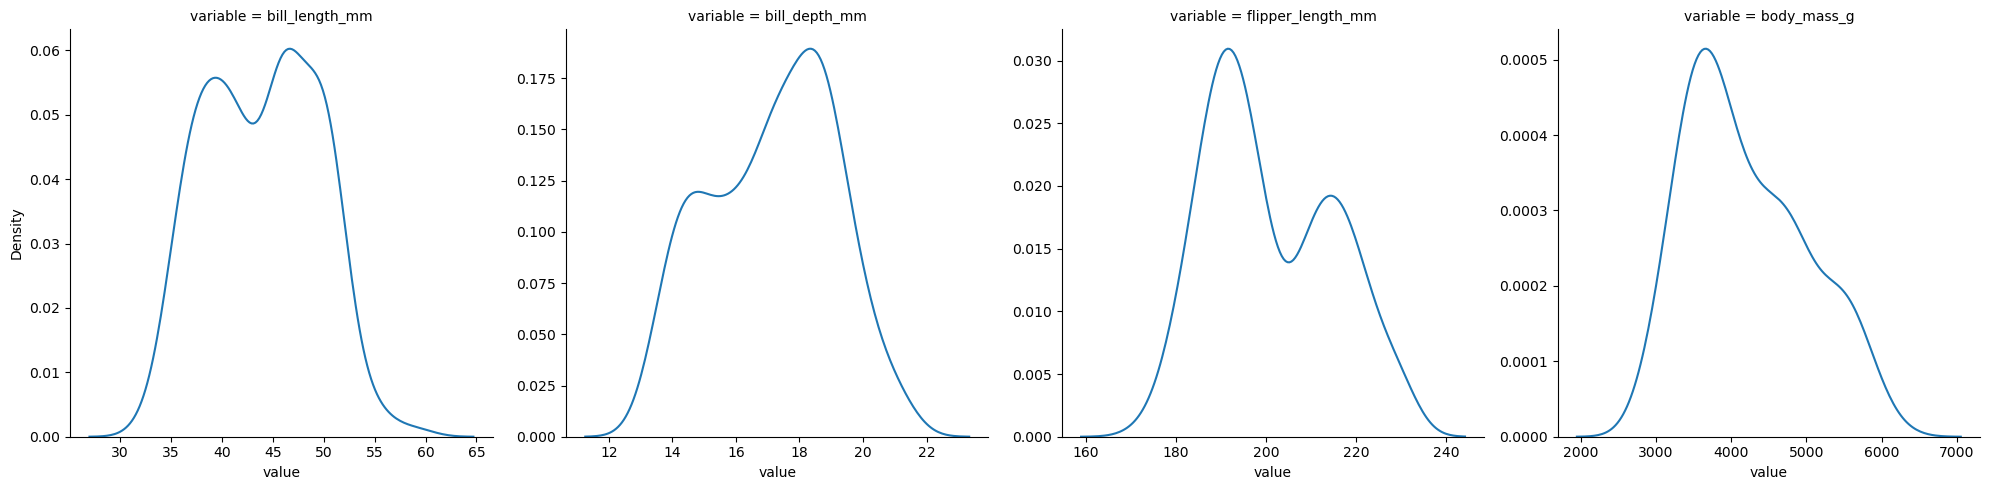

In [58]:
sns.displot( data = penguins_lf, x='value', col='variable', kind='kde',
            facet_kws={'sharex':False, 'sharey':False},
            common_norm=False)
plt.show()

Why is the LONG FORMAT so useful??

Because we can easily GROUP BY categorical variables!

We can group EACH facet by a categorical variable to study the CONDITIONAL DISTRIBUTION for each numeric column!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


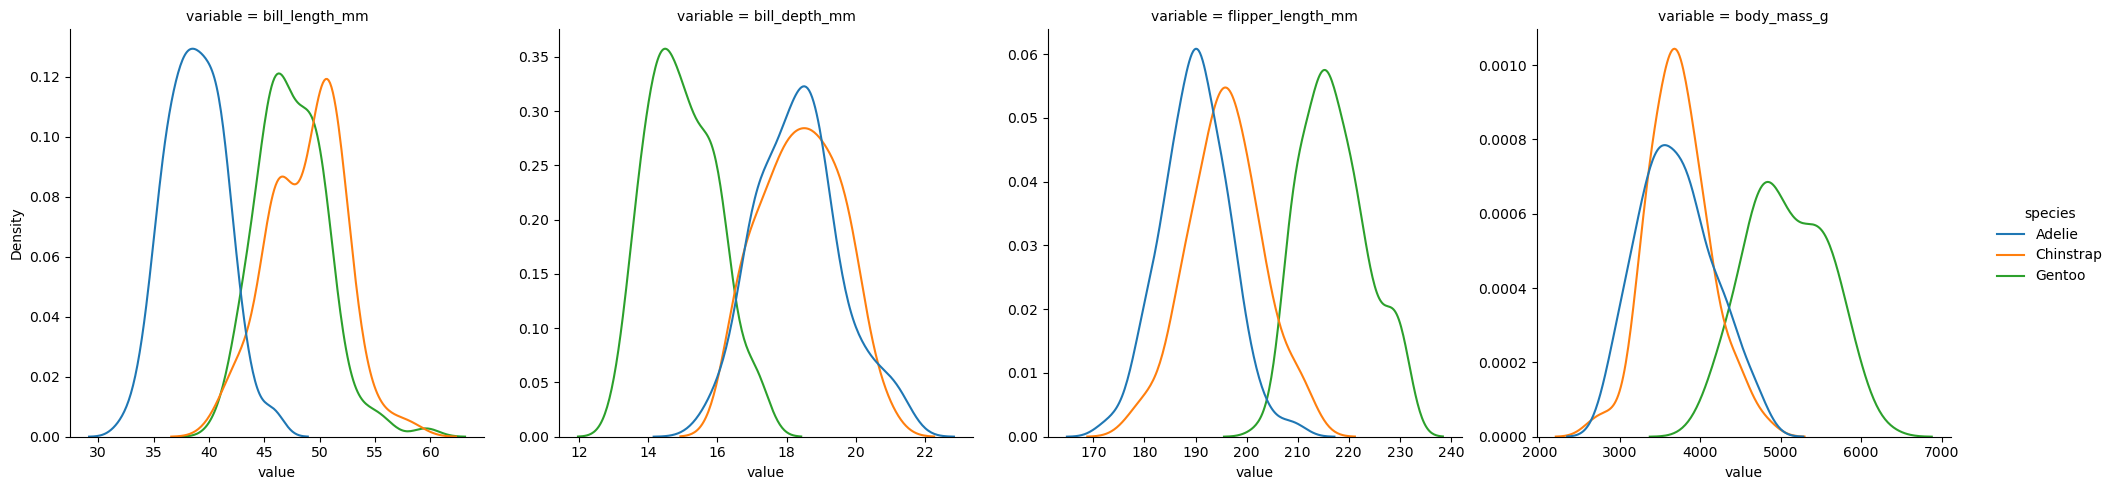

In [60]:
sns.displot( data = penguins_lf, x='value', col='variable', kind='kde',
            hue='species',
            facet_kws={'sharex':False, 'sharey':False},
            common_norm=False)
plt.show()

Since we have reshaped and we KEPT ALL non-numeric columns...We can FACET by other variables!!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


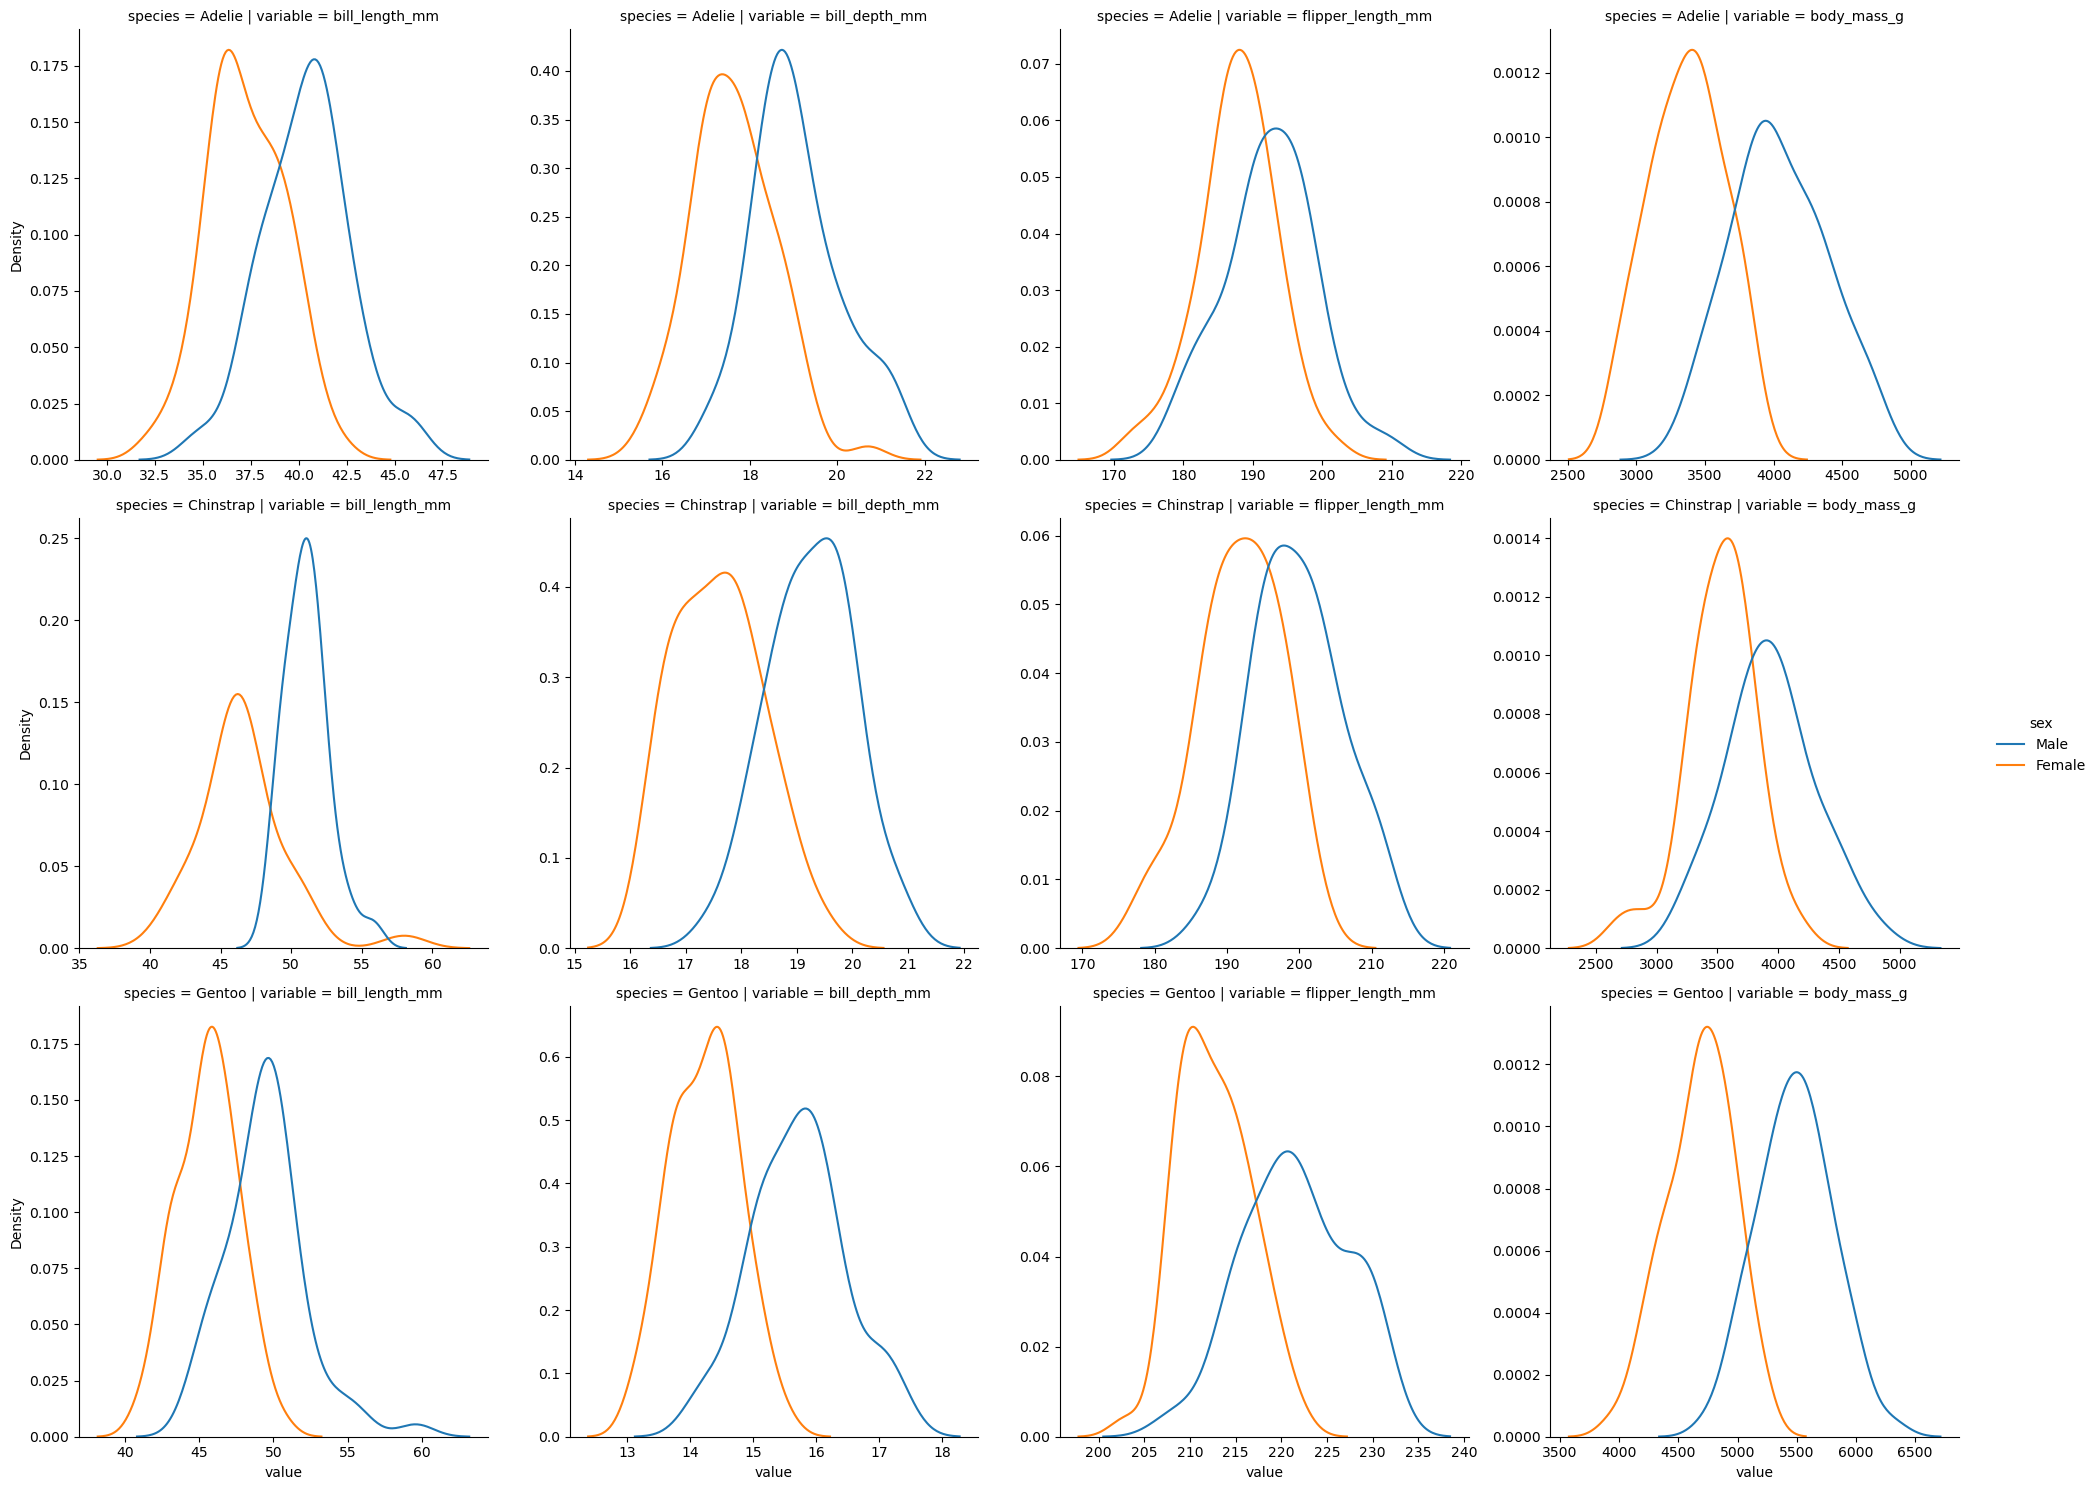

In [61]:
sns.displot( data = penguins_lf, x='value', col='variable', kind='kde',
            row='species', hue='sex',
            facet_kws={'sharex':False, 'sharey':False},
            common_norm=False)
plt.show()

We can use other types of plots from the long format without changing anything

We can show the CONDITIONAL distribution for each numeric column grouped by species as boxplot!

/opt/anaconda3/envs/cmpinf2100/lib/python3.8/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


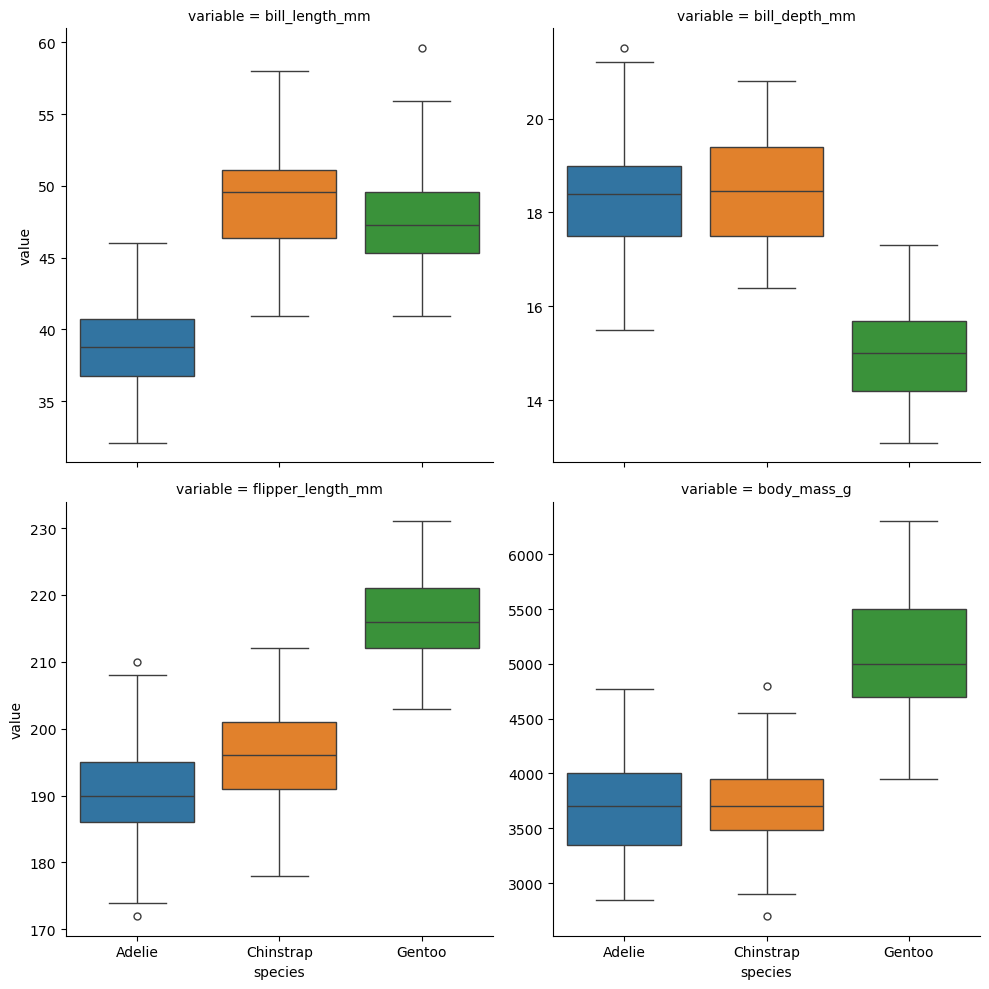

In [65]:
sns.catplot(data = penguins_lf, x='species', y='value', col='variable', hue='species', col_wrap=2,
            kind='box',
           sharey=False)
plt.show()